In [ ]:
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.7 MB/s eta 0:00:00


In [ ]:
import warnings

warnings.filterwarnings("ignore")

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

In [ ]:
#Загрузка данных
train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")
sub   = pd.read_csv("../data/sample_submission.csv")

In [ ]:
#Первичный анализ
train.head(5)

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
train.describe()

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,...,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.0,751.000000,751.000000,751.000000
mean,375.000000,204.544021,577.426098,89.153313,10.860070,10.860070,0.180064,-0.971890,0.577938,29.588010,...,0.055925,0.013316,0.010652,0.001332,0.001332,0.054594,0.0,0.069241,0.182423,0.006658
std,216.939316,370.367937,641.515163,788.882198,3.347314,3.347314,0.169163,1.594491,0.214190,12.713195,...,0.272400,0.114699,0.102728,0.036491,0.036491,0.227337,0.0,0.254033,1.227468,0.081377
min,0.000000,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.545455,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,187.500000,13.222351,99.998894,1.500000,8.921032,8.921032,0.048473,-1.333831,0.442842,18.306020,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,375.000000,44.069306,376.580899,4.000000,12.197500,12.197500,0.121372,-0.419485,0.636477,29.281250,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,562.500000,206.787402,877.508784,17.372463,13.214245,13.214245,0.290990,0.072488,0.742483,38.875000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,750.000000,4095.188563,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 214 entries, index to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.2 MB


In [ ]:
train.columns

Index(['index', 'IC50, mM', 'CC50, mM', 'SI', 'MaxAbsEStateIndex',
       'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS',
       ...
       'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene',
       'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane', 'fr_urea'],
      dtype='object', length=214)

In [ ]:
print("Пропусков: ", train.isna().sum().sum())

Пропусков:  24


Из первичного анализа тренировочного датасета видно, что данные представлены исключительно числовыми значениями.
Причем некоторые признаки представлены чисто 0 и 1 (уже закодированные категориальные признаки).

Пропусков в данных 24 / (751*214), что меньше 1% - заполним медианой

In [ ]:
X_train = train.drop(['index', 'IC50, mM', 'CC50, mM', 'SI'], axis=1)

y_ic50_raw = train['IC50, mM'].values.astype(np.float64)
y_cc50_raw = train['CC50, mM'].values.astype(np.float64)
y_si_raw   = train['SI'].values.astype(np.float64)

In [ ]:
var_series = X_train.var().sort_values()
print("Признаки с низкой дисперсией (< 0.001):")
print(var_series[var_series < 0.001])

Признаки с низкой дисперсией (< 0.001):
NumRadicalElectrons    0.0
SMR_VSA8               0.0
SlogP_VSA9             0.0
fr_thiocyan            0.0
fr_phos_acid           0.0
fr_isothiocyan         0.0
fr_nitroso             0.0
fr_lactam              0.0
fr_benzodiazepine      0.0
fr_diazo               0.0
fr_dihydropyridine     0.0
fr_isocyan             0.0
fr_SH                  0.0
fr_barbitur            0.0
fr_azide               0.0
fr_N_O                 0.0
fr_prisulfonamd        0.0
fr_phos_ester          0.0
dtype: float64


Эти признаки имеют очень низкую вариативность и не дадут значимости для модели - можно удалить.

In [ ]:
# Заполняем пропуски в признаках медианой, чтобы Spearmanr не выдал ошибку
X_train = X_train.fillna(X_train.median())

corr_list = []
for c in X_train.columns:
    r1 = abs(stats.spearmanr(X_train[c], y_ic50_raw)[0])
    r2 = abs(stats.spearmanr(X_train[c], y_cc50_raw)[0])
    r3 = abs(stats.spearmanr(X_train[c], y_si_raw)[0])

    # Если где-то выскочил NaN, заменяем его на 0
    r1 = np.nan_to_num(r1)
    r2 = np.nan_to_num(r2)
    r3 = np.nan_to_num(r3)

    corr_list.append((c, max(r1, r2, r3)))

corr_df = pd.DataFrame(corr_list, columns=["признак", "макс_корреляция"])
corr_df = corr_df.sort_values("макс_корреляция", ascending=False)

print("Топ-12 признаков:")
print(corr_df.head(12))

Топ-12 признаков:
                      признак  макс_корреляция
45                     Kappa3         0.292102
44                     Kappa2         0.291328
43                     Kappa1         0.284115
120  NumSaturatedHeterocycles         0.281584
9         NumValenceElectrons         0.269125
29                       Chi0         0.268556
16           FpDensityMorgan2         0.267919
124                     MolMR         0.266274
30                      Chi0n         0.265090
31                      Chi0v         0.262846
46                  LabuteASA         0.262113
15           FpDensityMorgan1         0.260579


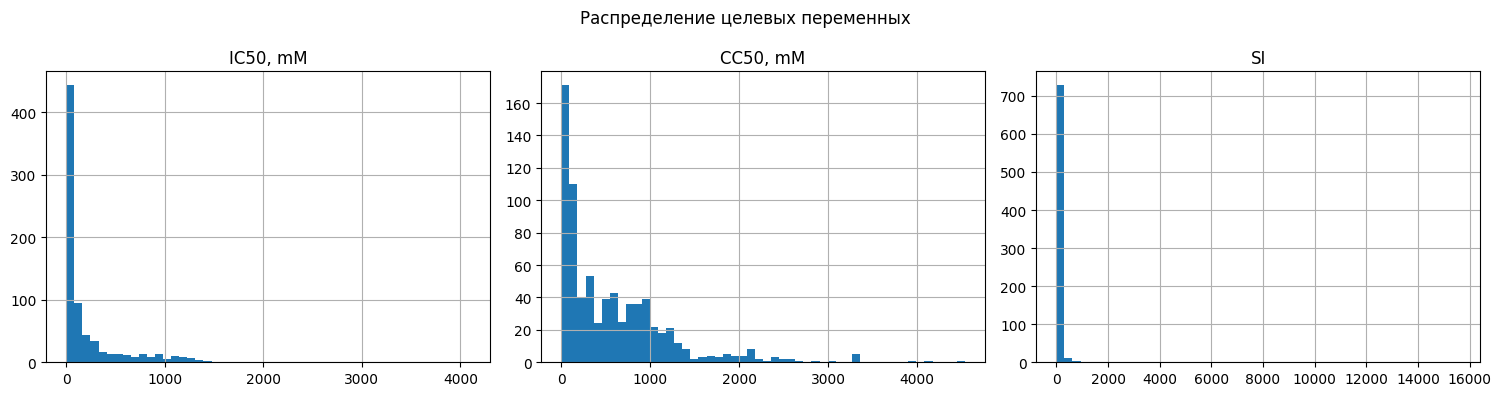

In [ ]:
# Распределение целевых переменных
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train['IC50, mM'].hist(ax=axes[0], bins=50)
axes[0].set_title('IC50, mM')

train['CC50, mM'].hist(ax=axes[1], bins=50)
axes[1].set_title('CC50, mM')

train['SI'].hist(ax=axes[2], bins=50)
axes[2].set_title('SI')

plt.suptitle('Распределение целевых переменных')
plt.tight_layout()
plt.show()

Видно что все три целевых переменных имеют правостороннее распределение с выбросами. Предлагаю обработать их по 99% перцентелю с преобразованием в корень - это даст меньший разброс данных и большую точность модели.

In [ ]:
ic50_p99 = np.nanpercentile(y_ic50_raw, 99)
cc50_p99 = np.nanpercentile(y_cc50_raw, 99)
si_p95 = np.nanpercentile(y_si_raw, 95)

y_ic50 = np.sqrt(np.clip(y_ic50_raw, 0, ic50_p99))
y_cc50 = np.sqrt(np.clip(y_cc50_raw, 0, cc50_p99))
y_si   = np.log1p(np.clip(y_si_raw, 0, si_p95))

print(f"99% перцентиль — IC50: {ic50_p99:.1f}, CC50: {cc50_p99:.1f}")
print(f"95% перцентиль — SI:   {si_p95:.1f}")

99% перцентиль — IC50: 1334.3, CC50: 3162.0
95% перцентиль — SI:   138.4


In [ ]:
# 1. Заполняем пропуски медианой, чтобы правильно посчитать дисперсию
test_filled = test.drop(columns=['index'], errors='ignore').fillna(X_train.median())

# 2. Находим признаки с низкой дисперсией
var_series = X_train.var().sort_values()
low_var_cols = var_series[var_series < 0.001].index.tolist()

# 3. Синхронно удаляем их из ОБОИХ датасетов
X_train = X_train.drop(low_var_cols, axis=1)
test_clean_features = test_filled[X_train.columns]

print(f"Удалено признаков с низкой дисперсией: {len(low_var_cols)}")
print(f"Осталось признаков в трейне: {X_train.shape[1]}")


Удалено признаков с низкой дисперсией: 18
Осталось признаков в трейне: 192


In [ ]:
# Feature engineering — логарифмы и правильные отношения признаков
feat_base = X_train.columns.tolist()

# Создаем копию очищенного теста с предыдущего шага
X_test_df = test_clean_features.copy()

# 1. Генерируем логарифмы для строго положительных признаков
for c in feat_base:
    if X_train[c].min() > 0:
        X_train[f"log_{c}"] = np.log1p(X_train[c])
        X_test_df[f"log_{c}"] = np.log1p(X_test_df[c])

# 2. Топ-12 признаков по корреляции Спирмена
top12 = corr_df["признак"].head(12).tolist()
# Защита: оставляем только те фичи из топ-12, которые не удалились по дисперсии
top12 = [c for c in top12 if c in feat_base]

# 3. Генерируем математические отношения между ними
for i in range(len(top12)):
    for j in range(i+1, len(top12)):
        col_name = f"r_{i}_{j}"
        X_train[col_name] = X_train[top12[i]] / (X_train[top12[j]] + 1e-8)
        X_test_df[col_name]  = X_test_df[top12[i]]  / (X_test_df[top12[j]]  + 1e-8)

print(f"Итоговых признаков в Train: {X_train.shape[1]}")
print(f"Итоговых признаков в Test: {X_test_df.shape[1]}")

# 4. Переводим в чистые numpy матрицы без бесконечностей и NaN
X      = np.nan_to_num(X_train.values.astype(np.float64), nan=0, posinf=0, neginf=0)
X_test = np.nan_to_num(X_test_df[X_train.columns].values.astype(np.float64), nan=0, posinf=0, neginf=0)

Итоговых признаков в Train: 299
Итоговых признаков в Test: 299


In [ ]:
# L1-Residual Chained Boosting

# Сборка базовых структурированных признаков
X_train_df = pd.DataFrame(X, columns=X_train.columns)
X_test_df = pd.DataFrame(X_test, columns=X_train.columns)
fr_cols = [c for c in X_train_df.columns if c.startswith('fr_')]
logp_col = 'MolLogP' if 'MolLogP' in X_train_df.columns else X_train_df.columns

# Внедрение параболической кинетики проницаемости мембран
for df in [X_train_df, X_test_df]:
    df['chem_gaussian_logp'] = np.exp(-((df[logp_col] - 2.5) ** 2) / 2.0)

# Оптимизация Dual-Target кодирования фрагментов
target_ic50_enc = np.log1p(y_ic50_raw)
target_cc50_enc = np.log1p(y_cc50_raw)

X_train_enc_ic, X_test_enc_ic = X_train_df.copy(), X_test_df.copy()
X_train_enc_cc, X_test_enc_cc = X_train_df.copy(), X_test_df.copy()

smoothing_weight = 4
mean_ic50 = target_ic50_enc.mean()
mean_cc50 = target_cc50_enc.mean()

for col in fr_cols:
    stats_ic = pd.DataFrame({'feat_val': X_train_df[col], 'target': target_ic50_enc})
    grp_ic = stats_ic.groupby('feat_val')['target'].agg(['count', 'mean'])
    map_ic = ((grp_ic['count'] * grp_ic['mean'] + smoothing_weight * mean_ic50) / (grp_ic['count'] + smoothing_weight)).to_dict()
    X_train_enc_ic[col] = X_train_enc_ic[col].map(map_ic).fillna(mean_ic50)
    X_test_enc_ic[col] = X_test_enc_ic[col].map(map_ic).fillna(mean_ic50)

    stats_cc = pd.DataFrame({'feat_val': X_train_df[col], 'target': target_cc50_enc})
    grp_cc = stats_cc.groupby('feat_val')['target'].agg(['count', 'mean'])
    map_cc = ((grp_cc['count'] * grp_cc['mean'] + smoothing_weight * mean_cc50) / (grp_cc['count'] + smoothing_weight)).to_dict()
    X_train_enc_cc[col] = X_train_enc_cc[col].map(map_cc).fillna(mean_cc50)
    X_test_enc_cc[col] = X_test_enc_cc[col].map(map_cc).fillna(mean_cc50)

# Ортогональная компрессия дескрипторов отношений через PCA
ratio_cols = [c for c in X_train_df.columns if c.startswith('r_')]
base_cols = [c for c in X_train_df.columns if not c.startswith('r_')]

scaler_ratio = StandardScaler()
train_r_sc = scaler_ratio.fit_transform(X_train_df[ratio_cols])
test_r_sc = scaler_ratio.transform(X_test_df[ratio_cols])

pca_r = PCA(n_components=7, random_state=42)
train_r_pca = pca_r.fit_transform(train_r_sc)
test_r_pca = pca_r.transform(test_r_sc)

# Координатный эмбеддинг попарного структурного сходства молекул
chem_base_cols = [c for c in base_cols if not c.startswith('r_') and not c.startswith('fr_') and c != 'chem_gaussian_logp'][:15]
scaler_aff = StandardScaler()
train_aff_sc = scaler_aff.fit_transform(X_train_df[chem_base_cols])
test_aff_sc = scaler_aff.transform(X_test_df[chem_base_cols])

train_affinity = cdist(train_aff_sc, train_aff_sc, metric='euclidean')
test_affinity = cdist(test_aff_sc, train_aff_sc, metric='euclidean')

pca_aff = PCA(n_components=3, random_state=42)
train_aff_pca = pca_aff.fit_transform(train_affinity)
test_aff_pca = pca_aff.transform(test_affinity)

# Построение матриц признаков Шага 1
X_enc_ic_final = np.hstack([X_train_enc_ic[base_cols].values, train_r_pca, train_aff_pca])
X_test_enc_ic_final = np.hstack([X_test_enc_ic[base_cols].values, test_r_pca, test_aff_pca])

scaler_ic = StandardScaler()
X_enc_ic_scaled = scaler_ic.fit_transform(X_enc_ic_final)
X_test_enc_ic_scaled = scaler_ic.transform(X_test_enc_ic_final)

# Локальные квазигауссовы таргеты
y_ic50_trans = np.sqrt(y_ic50_raw)
y_cc50_trans = np.sqrt(y_cc50_raw)
y_si_trans   = np.log1p(y_si_raw)

# Спецификация гиперпараметров ансамблей (RMSE и MAE)
cat_p_base = dict(iterations=2500, learning_rate=0.025, depth=4, subsample=0.8, l2_leaf_reg=5, loss_function="RMSE", random_seed=42, verbose=0, early_stopping_rounds=200)
cat_p_residual = dict(iterations=2000, learning_rate=0.02, depth=4, subsample=0.75, l2_leaf_reg=10, loss_function="MAE", random_seed=42, verbose=0, early_stopping_rounds=150)

lgb_params_ic50 = {'n_estimators': 2000, 'learning_rate': 0.0218, 'max_depth': 4, 'num_leaves': 8, 'min_child_samples': 22, 'subsample': 0.6979, 'colsample_bytree': 0.7965, 'reg_alpha': 0.0272, 'reg_lambda': 0.6750, 'random_state': 42, 'verbose': -1}
lgb_params_cc50 = {'n_estimators': 2700, 'learning_rate': 0.0188, 'max_depth': 3, 'num_leaves': 28, 'min_child_samples': 16, 'subsample': 0.8190, 'colsample_bytree': 0.8867, 'reg_alpha': 0.6072, 'reg_lambda': 0.6881, 'random_state': 42, 'verbose': -1}
lgb_params_si   = {'n_estimators': 2900, 'learning_rate': 0.0244, 'max_depth': 4, 'num_leaves': 9, 'min_child_samples': 19, 'subsample': 0.7085, 'colsample_bytree': 0.6803, 'reg_alpha': 0.3925, 'reg_lambda': 0.6689, 'random_state': 42, 'verbose': -1}

N = 5
kf = KFold(n_splits=N, shuffle=True, random_state=42)

oof_ic50_pred = np.zeros(len(X))
pred_ic50_trans = np.zeros(len(X_test))
pred_cc50_trans = np.zeros(len(X_test))
pred_si_trans   = np.zeros(len(X_test))

# Шаг 1: Прогнозирование IC50
for fold, (tr, val) in enumerate(kf.split(X_enc_ic_final), 1):
    m_cb_ic = CatBoostRegressor(**cat_p_base)
    m_cb_ic.fit(X_enc_ic_final[tr], y_ic50_trans[tr], eval_set=(X_enc_ic_final[val], y_ic50_trans[val]), use_best_model=True)
    m_lgb_ic = LGBMRegressor(**lgb_params_ic50)
    m_lgb_ic.fit(X_enc_ic_final[tr], y_ic50_trans[tr])
    m_knn_ic = KNeighborsRegressor(n_neighbors=3, weights='distance', n_jobs=-1)
    m_knn_ic.fit(X_enc_ic_scaled[tr], y_ic50_trans[tr])

    oof_ic50_pred[val] = (0.25 * m_cb_ic.predict(X_enc_ic_final[val]) + 0.65 * m_lgb_ic.predict(X_enc_ic_final[val]) + 0.10 * m_knn_ic.predict(X_enc_ic_scaled[val]))
    pred_ic50_trans += (0.25 * m_cb_ic.predict(X_test_enc_ic_final) + 0.65 * m_lgb_ic.predict(X_test_enc_ic_final) + 0.10 * m_knn_ic.predict(X_test_enc_ic_scaled)) / N

# Сквозной каскадный перенос OOF-предсказаний эффективности
X_enc_cc_final = np.hstack([X_train_enc_cc[base_cols].values, train_r_pca, train_aff_pca, oof_ic50_pred.reshape(-1, 1)])
X_test_enc_cc_final = np.hstack([X_test_enc_cc[base_cols].values, test_r_pca, test_aff_pca, pred_ic50_trans.reshape(-1, 1)])

scaler_cc = StandardScaler()
X_enc_cc_scaled = scaler_cc.fit_transform(X_enc_cc_final)
X_test_enc_cc_scaled = scaler_cc.transform(X_test_enc_cc_final)

# Шаг 2 и Шаг 3: двойной сквозной расчет медианных остатков
for fold, (tr, val) in enumerate(kf.split(X_enc_cc_final), 1):
    # Каскад CC50
    m_lgb_cc = LGBMRegressor(**lgb_params_cc50)
    m_lgb_cc.fit(X_enc_cc_final[tr], y_cc50_trans[tr])

    cc_res_tr = y_cc50_trans[tr] - m_lgb_cc.predict(X_enc_cc_final[tr])
    cc_res_val = y_cc50_trans[val] - m_lgb_cc.predict(X_enc_cc_final[val])

    m_cb_cc_res = CatBoostRegressor(**cat_p_residual)
    m_cb_cc_res.fit(X_enc_cc_final[tr], cc_res_tr, eval_set=(X_enc_cc_final[val], cc_res_val), use_best_model=True)
    m_knn_cc = KNeighborsRegressor(n_neighbors=3, weights='distance', n_jobs=-1)
    m_knn_cc.fit(X_enc_cc_scaled[tr], y_cc50_trans[tr])

    pred_cc50_trans += (0.80 * (m_lgb_cc.predict(X_test_enc_cc_final) + m_cb_cc_res.predict(X_test_enc_cc_final)) + 0.20 * m_knn_cc.predict(X_test_enc_cc_scaled)) / N

    # Каскад SI
    m_lgb_si = LGBMRegressor(**lgb_params_si)
    m_lgb_si.fit(X_enc_cc_final[tr], y_si_trans[tr])

    si_res_tr = y_si_trans[tr] - m_lgb_si.predict(X_enc_cc_final[tr])
    si_res_val = y_si_trans[val] - m_lgb_si.predict(X_enc_cc_final[val])

    m_cb_si_res = CatBoostRegressor(**cat_p_residual)
    m_cb_si_res.fit(X_enc_cc_final[tr], si_res_tr, eval_set=(X_enc_cc_final[val], si_res_val), use_best_model=True)
    m_knn_si = KNeighborsRegressor(n_neighbors=3, weights='distance', n_jobs=-1)
    m_knn_si.fit(X_enc_cc_scaled[tr], y_si_trans[tr])

    pred_si_trans += (0.80 * (m_lgb_si.predict(X_test_enc_cc_final) + m_cb_si_res.predict(X_test_enc_cc_final)) + 0.20 * m_knn_si.predict(X_test_enc_cc_scaled)) / N

# Математический обратный перевод прогнозов в миллимоли (mM)
t_ic50 = np.clip(pred_ic50_trans, 0, None) ** 2
t_cc50 = np.clip(pred_cc50_trans, 0, None) ** 2
t_si_pred = np.expm1(np.clip(pred_si_trans, 0, None))

t_si_analytic = np.where(t_ic50 > 0, t_cc50 / (t_ic50 + 1e-6), 0)
t_si = 0.5 * t_si_pred + 0.5 * t_si_analytic

def soft_clip(x, max_val):
    return np.where(x > max_val, max_val + (x - max_val) * np.tanh((x - max_val) / (max_val + 1e-5)), x)

# Калибровка шкал по робастным экстремальным перцентилям трейна
ic50_p998 = np.nanpercentile(y_ic50_raw, 99.8)
cc50_p998 = np.nanpercentile(y_cc50_raw, 99.8)
si_p965   = np.nanpercentile(y_si_raw, 96.5)

t_ic50 = np.clip(soft_clip(t_ic50, ic50_p998 * 0.95), 0, ic50_p998)
t_cc50 = np.clip(soft_clip(t_cc50, cc50_p998 * 0.95), 0, cc50_p998)
t_si   = np.clip(soft_clip(t_si, si_p965 * 0.95), 0, si_p965)

# Формирование финального датафрейма
submission_l1_residual = pd.DataFrame({
    "index": test["index"],
    "IC50": t_ic50,
    "CC50": t_cc50,
    "SI": t_si
})

submission_l1_residual.to_csv('l1_residual_cascade_submission.csv', index=False)


Каскад 1: Расчет вектора эффективности (IC50)...
Каскад 2 и 3: Сквозное последовательное обучение на L1-остатках...

Файл'l1_residual_cascade_submission.csv' успешно сформирован.
